In [1]:
import pandas as pd

df = pd.read_csv("04-jogja-apr-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM2.5,PM10,SO2,CO,O3,NO2,Max,Critical Component,Category
1,4/1/2021,00:00:00,45,19,21,15,8.0,3,21,PM2.5,Good
2,4/1/2021,01:00:00,44,18,20,14,8.0,3,20,PM2.5,Good
3,4/1/2021,02:00:00,43,17,20,14,7.0,3,20,PM2.5,Good
4,4/1/2021,03:00:00,40,17,20,13,7.0,3,20,PM2.5,Good
5,4/1/2021,04:00:00,38,16,19,12,7.0,3,19,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,4/30/2021,19:00:00,54,23,17,14,NaN,4,23,PM2.5,Good
717,4/30/2021,20:00:00,54,23,17,14,NaN,4,23,PM2.5,Good
718,4/30/2021,21:00:00,54,23,17,13,NaN,4,23,PM2.5,Good
719,4/30/2021,22:00:00,54,23,17,13,NaN,4,23,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [2]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 04-jogja-apr-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    str    
 1   Time                720 non-null    str    
 2   PM2.5               720 non-null    int64  
 3   PM10                720 non-null    int64  
 4   SO2                 720 non-null    int64  
 5   CO                  720 non-null    int64  
 6   O3                  621 non-null    float64
 7   NO2                 720 non-null    int64  
 8   Max                 720 non-null    int64  
 9   Critical Component  720 non-null    str    
 10  Category            720 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 62.0 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [3]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 04-jogja-apr-2021.csv


,PM2.5,PM10,SO2,CO,O3,NO2,Max
count,720.000000,720.000000,720.000000,720.000000,621.000000,720.000000,720.000000
mean,44.290278,18.830556,16.641667,11.547222,23.774557,3.848611,25.137500
std,10.556183,6.091482,3.306661,4.215409,9.962708,1.487312,8.569716
min,19.000000,8.000000,11.000000,5.000000,7.000000,2.000000,14.000000
25%,35.000000,14.000000,14.000000,9.000000,18.000000,3.000000,20.000000
50%,45.000000,18.000000,16.000000,11.000000,21.000000,3.000000,23.000000
75%,53.000000,23.000000,19.000000,13.000000,27.000000,5.000000,27.000000
max,66.000000,36.000000,28.000000,24.000000,65.000000,8.000000,65.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [4]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 04-jogja-apr-2021.csv


Critical Component
PM2.5    91.666667
O3        8.333333
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [5]:
filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 04-jogja-apr-2021.csv


Category
Good        97.5
Moderate     2.5
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 04-jogja-apr-2021.csv


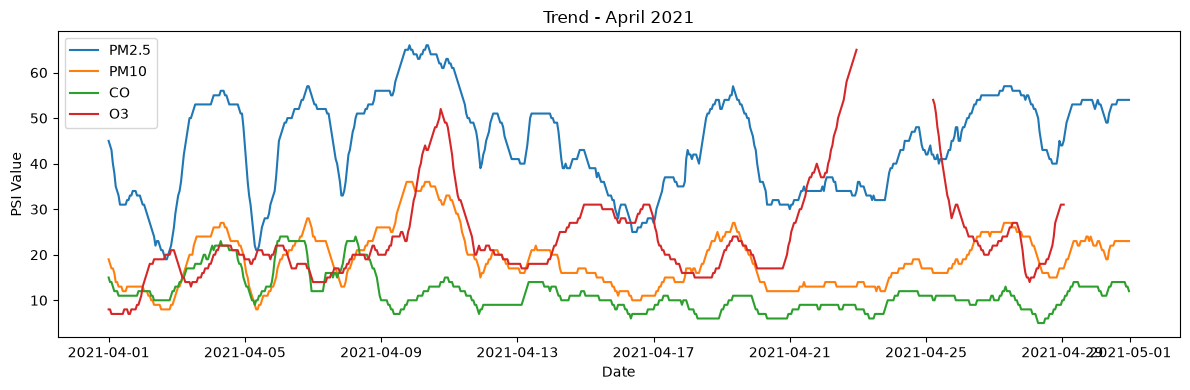

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the April data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - April 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In April 2021, PM2.5 was still the highest most of the time (roughly 15-65), O3 spiked a few times sharply (like around April 9 and April 23) but stayed low in between, while PM10 and CO stayed low and fairly steady all month.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 04-jogja-apr-2021.csv


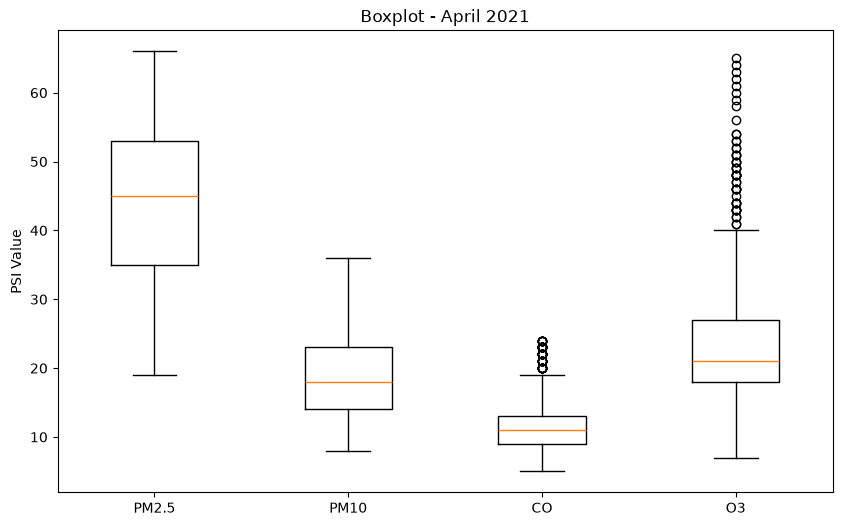

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - April 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**In April 2021, PM2.5 had the highest median (45) and had no outliers, PM10 also had no outliers, while CO and O3 had high outliers, and O3 had the most.**

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 04-jogja-apr-2021.csv


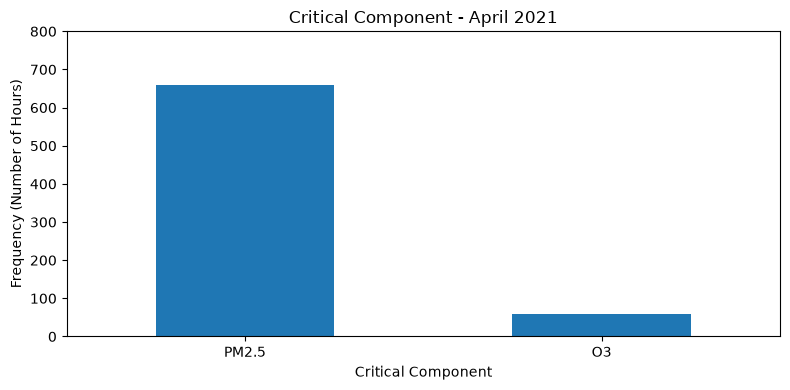

Critical Component
PM2.5    660
O3        60
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "04-jogja-apr-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - April 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  # Display the counts for each bar of Critical Component